In [1]:
import sys
sys.path.append('../code')

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from memorycontext_nodendrite_initialize_sweep import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

/users/ntolley/.conda/envs/jaxley/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
comp = jx.Compartment()
branch = jx.Branch(comp, ncomp=1)

E_cell = jx.Cell(branch, parents=[-1])
I_cell = jx.Cell(branch, parents=[-1])
context_cell = jx.Cell()
cue_cell = jx.Cell()
rate_cell = jx.Cell()
output_cell = jx.Cell()

num_E_cells = 100
num_I_cells = 50
num_context_cells = 50
num_cue_cells = 50

net_dict = {
    'E': {'num_cells': num_E_cells, 'cell': E_cell},
    'I': {'num_cells': num_I_cells, 'cell': I_cell},
    'context': {'num_cells': num_context_cells, 'cell': context_cell},
    'cue': {'num_cells': num_cue_cells, 'cell': cue_cell},
    'E_rate': {'num_cells': num_E_cells, 'cell': rate_cell},
    'I_rate': {'num_cells': num_I_cells, 'cell': rate_cell},
}

gid_ranges = dict()
cell_list = list()
cell_count = 0
for name, cell_dict in net_dict.items():
    num_cells = cell_dict['num_cells']
    gid_ranges[name] = range(cell_count, cell_count + num_cells)
    cell_list.extend([cell_dict['cell'] for _ in range(num_cells)])
    cell_count += num_cells




In [3]:
# net, gid_ranges = make_network()
# with open('jaxley_net.pkl', 'wb') as f:
#     pickle.dump((net, gid_ranges),f)

# with open('jaxley_net.pkl', 'rb') as f:
#     net, gid_ranges = pickle.load(f)

# num_E_cells, num_I_cells = len(gid_ranges['E']), len(gid_ranges['I'])
# num_cue_cells = len(gid_ranges['cue'])

# parameters, _ = set_train_parameters(net, gid_ranges)
prior_dict = get_prior_dict()

In [4]:
# data_path = '/users/ntolley/data/ntolley/dendractor/memorycontext_dendrite/'
data_path = '/users/ntolley/data/ntolley/dendractor/memorycontext_nodendrite/'

t_max = 2000
dt = 0.25
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [5]:
input_list = jnp.array([[-2,-2,1], [2,2,1], [-2, 2,1], [2,-2,1],
                       [-2,-2,-1], [2,2,-1], [-2, 2,-1], [2,-2,-1]])
num_cond = input_list.shape[0]
input_data = [get_currents(input_list[idx], gid_ranges, t_max=t_max, dt=0.025) for idx in range(num_cond)]
targets = np.concatenate([input_data[idx][2][:, ::10] for idx in range(num_cond)], axis=1).T


In [6]:
theta_list = list()
error_list = list()
band_power_list = list()

num_flows = 5
for flow_idx in range(num_flows):
    print(f'Flow {flow_idx}')
    theta = np.load(f'{data_path}/theta_{flow_idx}.npy')
    error = np.load(f'{data_path}/flow_error_{flow_idx}.npy')
    band_power_avg = np.load(f'{data_path}/flow_band_power_{flow_idx}.npy')


    rate_gids = list(gid_ranges['E_rate']) + list(gid_ranges['I_rate'])
    voltage_gids = list(gid_ranges['E'])

    if flow_idx == num_flows - 1:
        x_out = np.load(f'{data_path}/x_out_{flow_idx}.npy')
        rates = x_out[:, rate_gids, :]
        voltages = x_out[:, voltage_gids, :]
        num_sims, num_neurons, num_samples = rates.shape
    theta_list.append(theta)
    error_list.append(error)
    band_power_list.append(band_power_avg)


error_sort = np.argsort(error)

Flow 0
Flow 1
Flow 2
Flow 3
Flow 4


In [7]:
fs_flow = 1e3 / 0.25
rates_stacked = rates.reshape((num_sims * num_neurons, num_samples))
freqs, spectrum = compute_spectrum(rates_stacked, fs=fs_flow, nperseg=fs_flow*5)
spectrum = spectrum.reshape((num_sims, num_neurons, -1))


# freq_mask = np.logical_and(freqs > 10, freqs < 40)


/users/ntolley/.conda/envs/jaxley/lib/python3.11/site-packages/neurodsp/spectral/power.py:219: UserWarning: nperseg = 20000 is greater than input length  = 8001, using nperseg = 8001
  freqs, _, spg = spectrogram(sig, fs, window, nperseg, noverlap)


In [8]:
freq_mask = np.logical_and(freqs > 10, freqs < 40)
avg_spectrum = np.mean(spectrum, axis=1)
np.sum(avg_spectrum[:, freq_mask], axis=1)

array([0.00431232, 0.00214435, 0.00153479, ..., 0.00222802, 0.00160261,
       0.00507718])

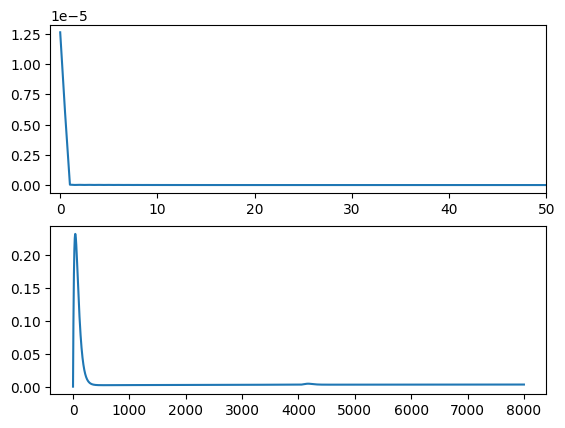

In [19]:
neuron_idx = 50400
plt.subplot(2,1,1)
plt.plot(*compute_spectrum(rates_stacked[neuron_idx,:], fs=fs_flow, nperseg=fs_flow*5))
plt.xlim(-1,50)
plt.subplot(2,1,2)
plt.plot(rates_stacked[neuron_idx,:])

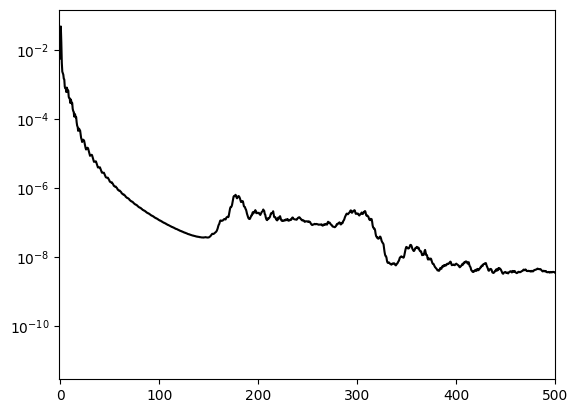

In [20]:
spectrum_avg = np.mean(spectrum, axis=(0,1))
# std across simulations, first average across neurons
spectrum_std = np.std(np.mean(spectrum, axis=1), axis=0)

plt.plot(freqs, spectrum_avg, color='k')

plt.xlim(-1,500)
plt.yscale('log')

In [21]:
output_array = x_out.copy()

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)
band_power_avg = np.array(band_power_avg)
band_power_sort = np.argsort(band_power_avg)[::-1]



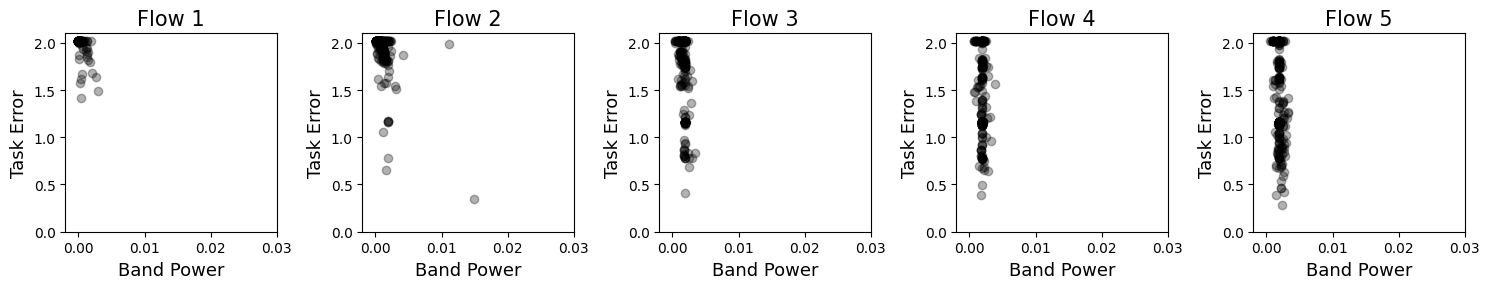

In [23]:
plt.figure(figsize=(3 * num_flows,3))
error_avg, error_std = list(), list()
band_power_avg, band_power_std = list(), list()

for idx in range(num_flows):
    plt.subplot(1,num_flows,idx+1)
    plt.scatter(band_power_list[idx], error_list[idx], color=f"k", alpha=0.3)
    plt.title(f'Flow {idx+1}', fontsize=15)
    plt.xlim(-0.002, 0.030)
    plt.ylim(0, 2.1)
    plt.xlabel('Band Power', fontsize=13)
    plt.ylabel('Task Error', fontsize=13)

    error_avg.append(np.mean(error_list[idx]))
    error_std.append(np.std(error_list[idx]))

    band_power_avg.append(np.mean(band_power_list[idx]))
    band_power_std.append(np.std(band_power_list[idx]))

plt.tight_layout()
plt.savefig('../figures/memorycontext_dendrite_optimization.svg')

In [24]:
opt_dict = {'flow_idx': list(range(num_flows)),
            'error_avg': error_avg, 'error_std': error_std,
            'band_power_avg': band_power_avg, 'band_power_std': band_power_std}
opt_df = pd.DataFrame(opt_dict)
opt_df.to_csv('../data/memorycontext_dendrite_optimization.svg')


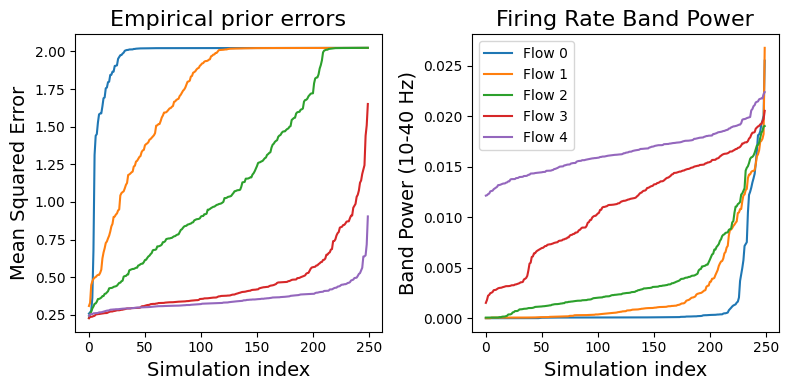

In [25]:
plt.figure(figsize=(8,4))
fontsize = 14
for idx in range(num_flows):
    plt.subplot(1,2,1)
    plt.plot(np.sort(error_list[idx]), label=f'Flow {idx}')
    plt.title('Empirical prior errors', fontsize=fontsize+2)
    plt.ylabel('Mean Squared Error', fontsize=fontsize)
    plt.xlabel('Simulation index', fontsize=fontsize)

    plt.subplot(1,2,2)
    plt.plot(np.sort(band_power_list[idx]), label=f'Flow {idx}')
    plt.xlabel('Simulation index', fontsize=fontsize)
    plt.ylabel('Band Power (10-40 Hz)', fontsize=fontsize)
    plt.title('Firing Rate Band Power', fontsize=fontsize+2)
plt.legend()
plt.tight_layout()

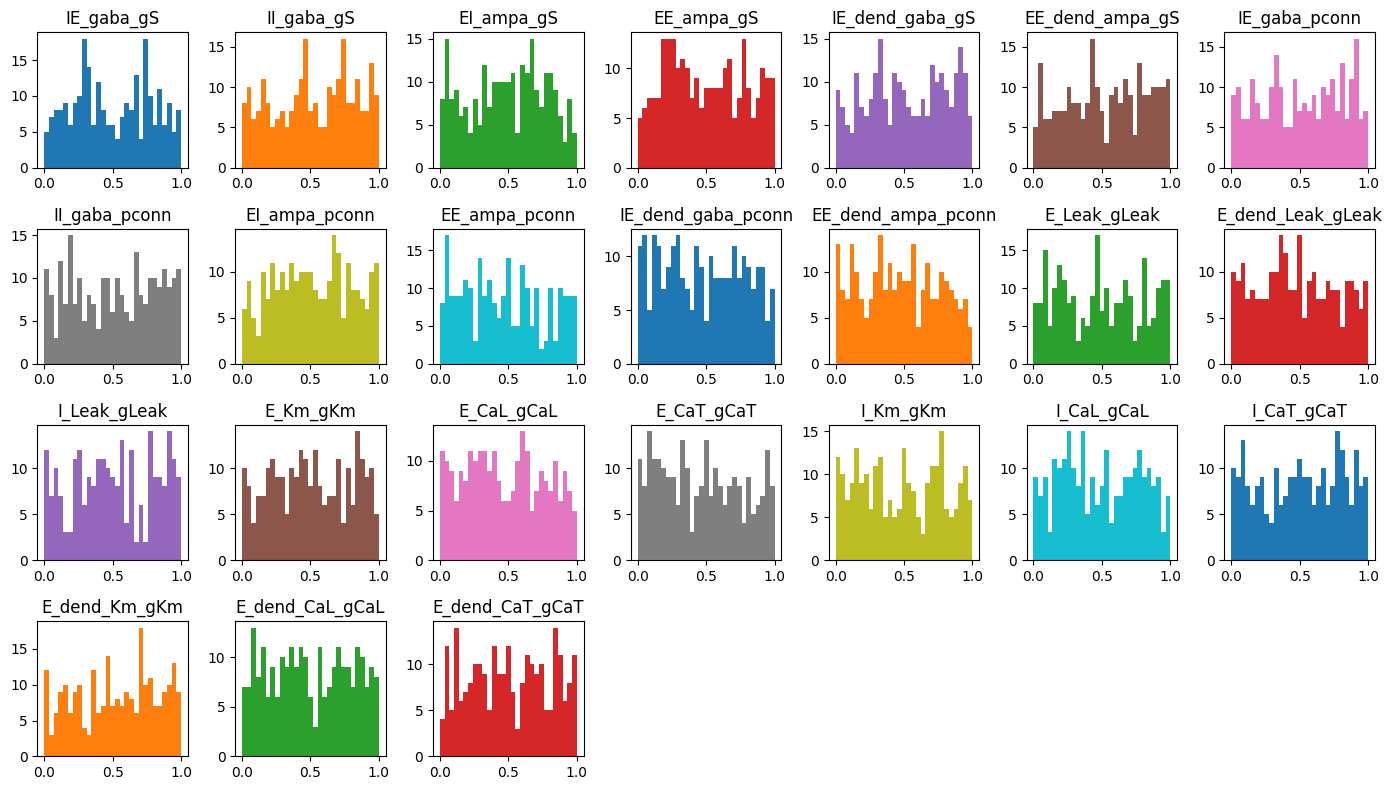

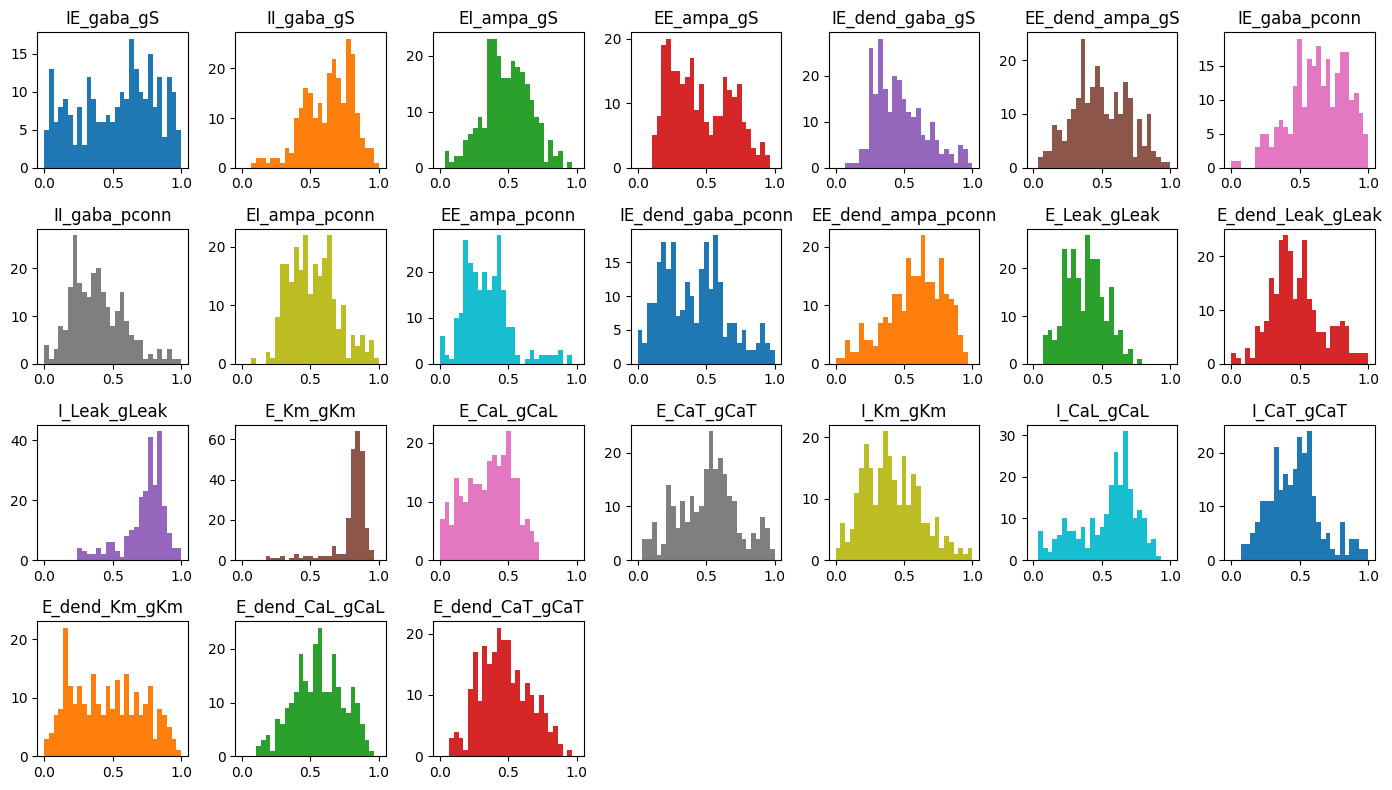

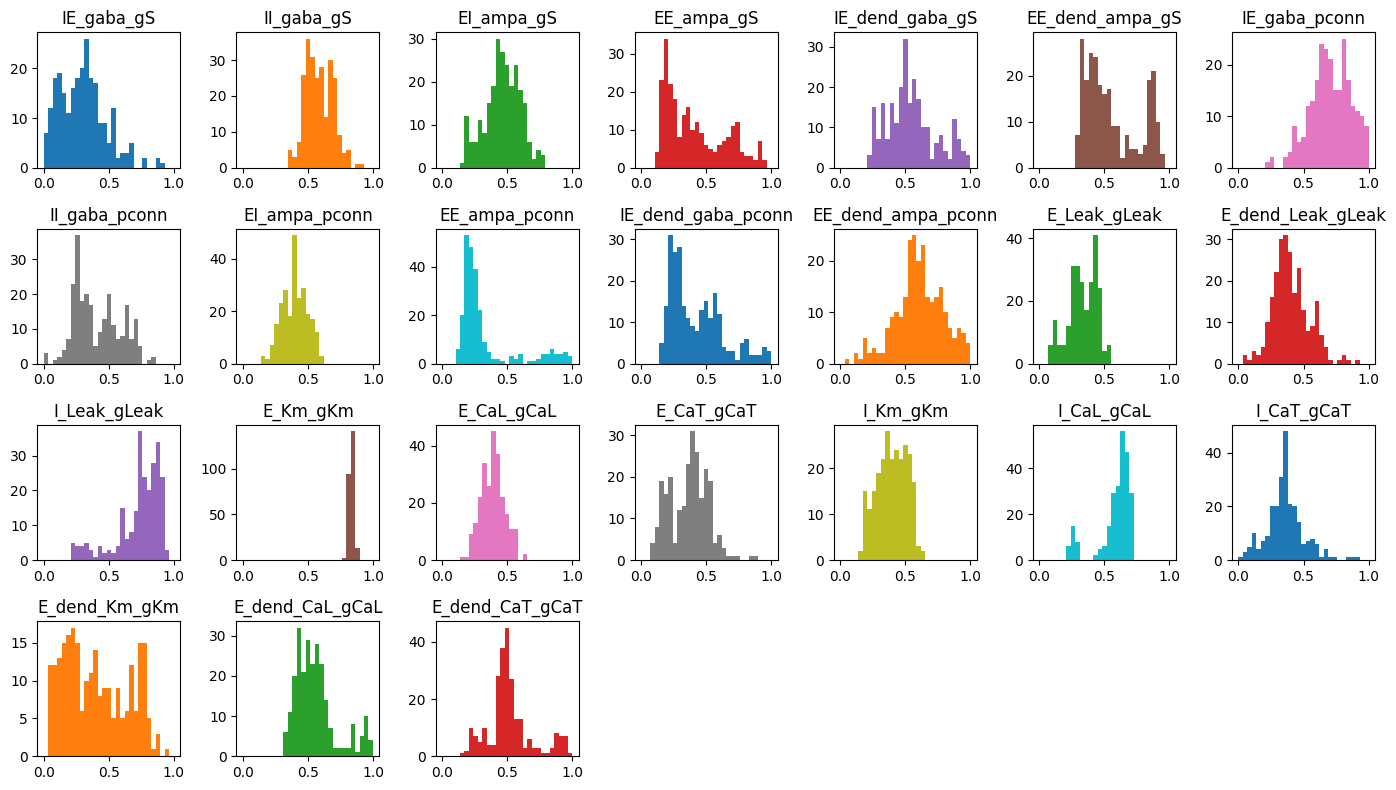

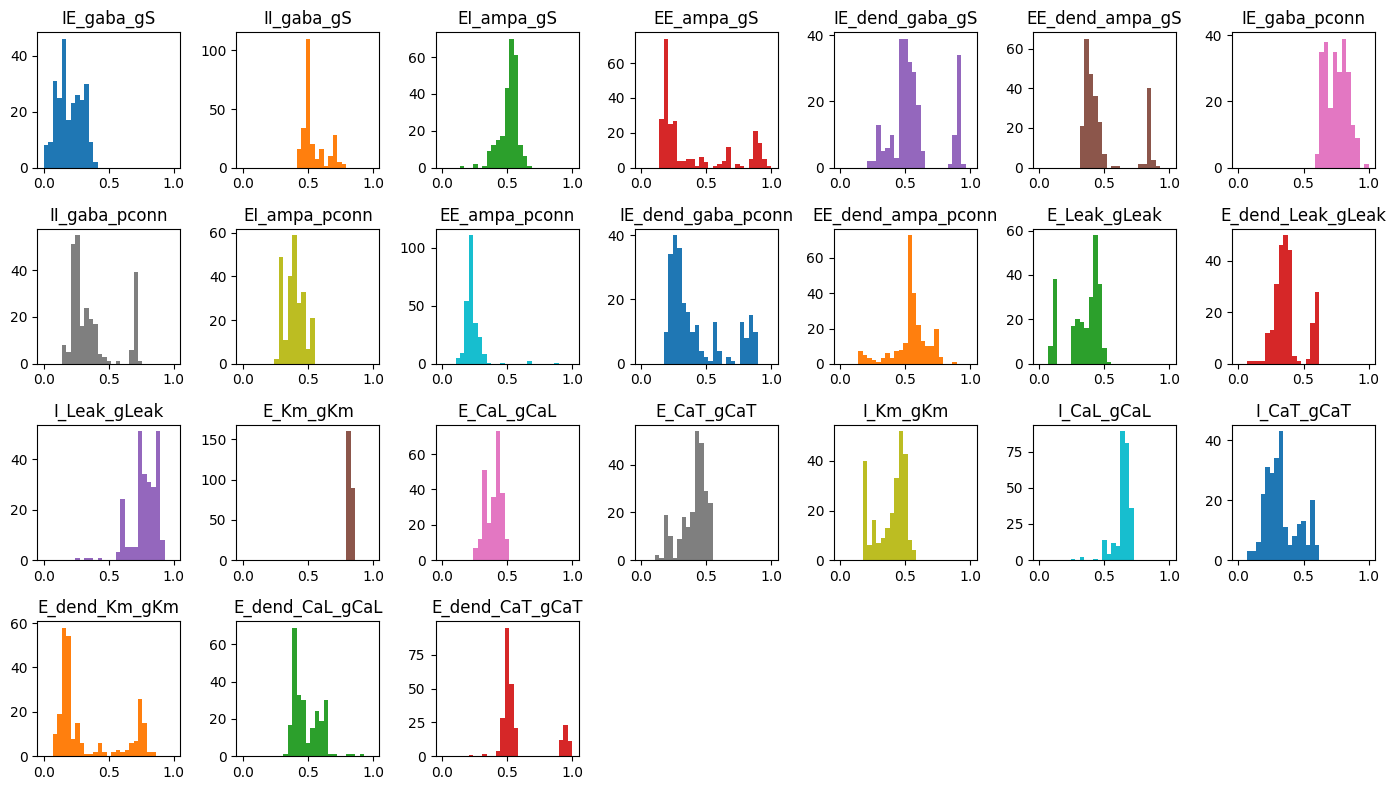

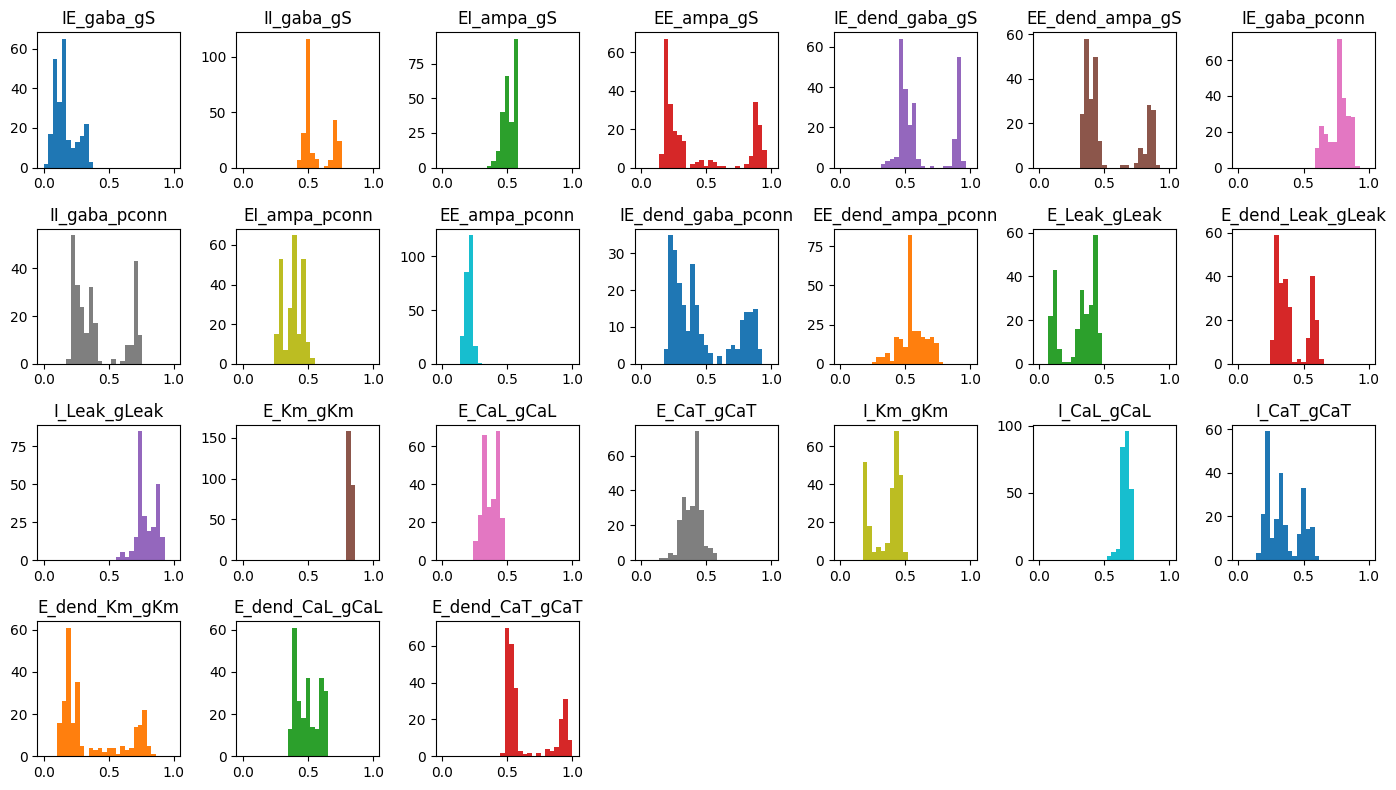

In [25]:
param_names = list(prior_dict.keys())

for idx in range(num_flows):
    plt.figure(figsize=(14,8))
    for param_idx in range(theta.shape[1]):
        bins = np.linspace(0, 1, 30)
        plt.subplot(4,7, param_idx+1)
        _ = plt.hist(theta_list[idx][:, param_idx], bins=bins, color=f'C{param_idx}')
        plt.title(param_names[param_idx])
    plt.tight_layout()

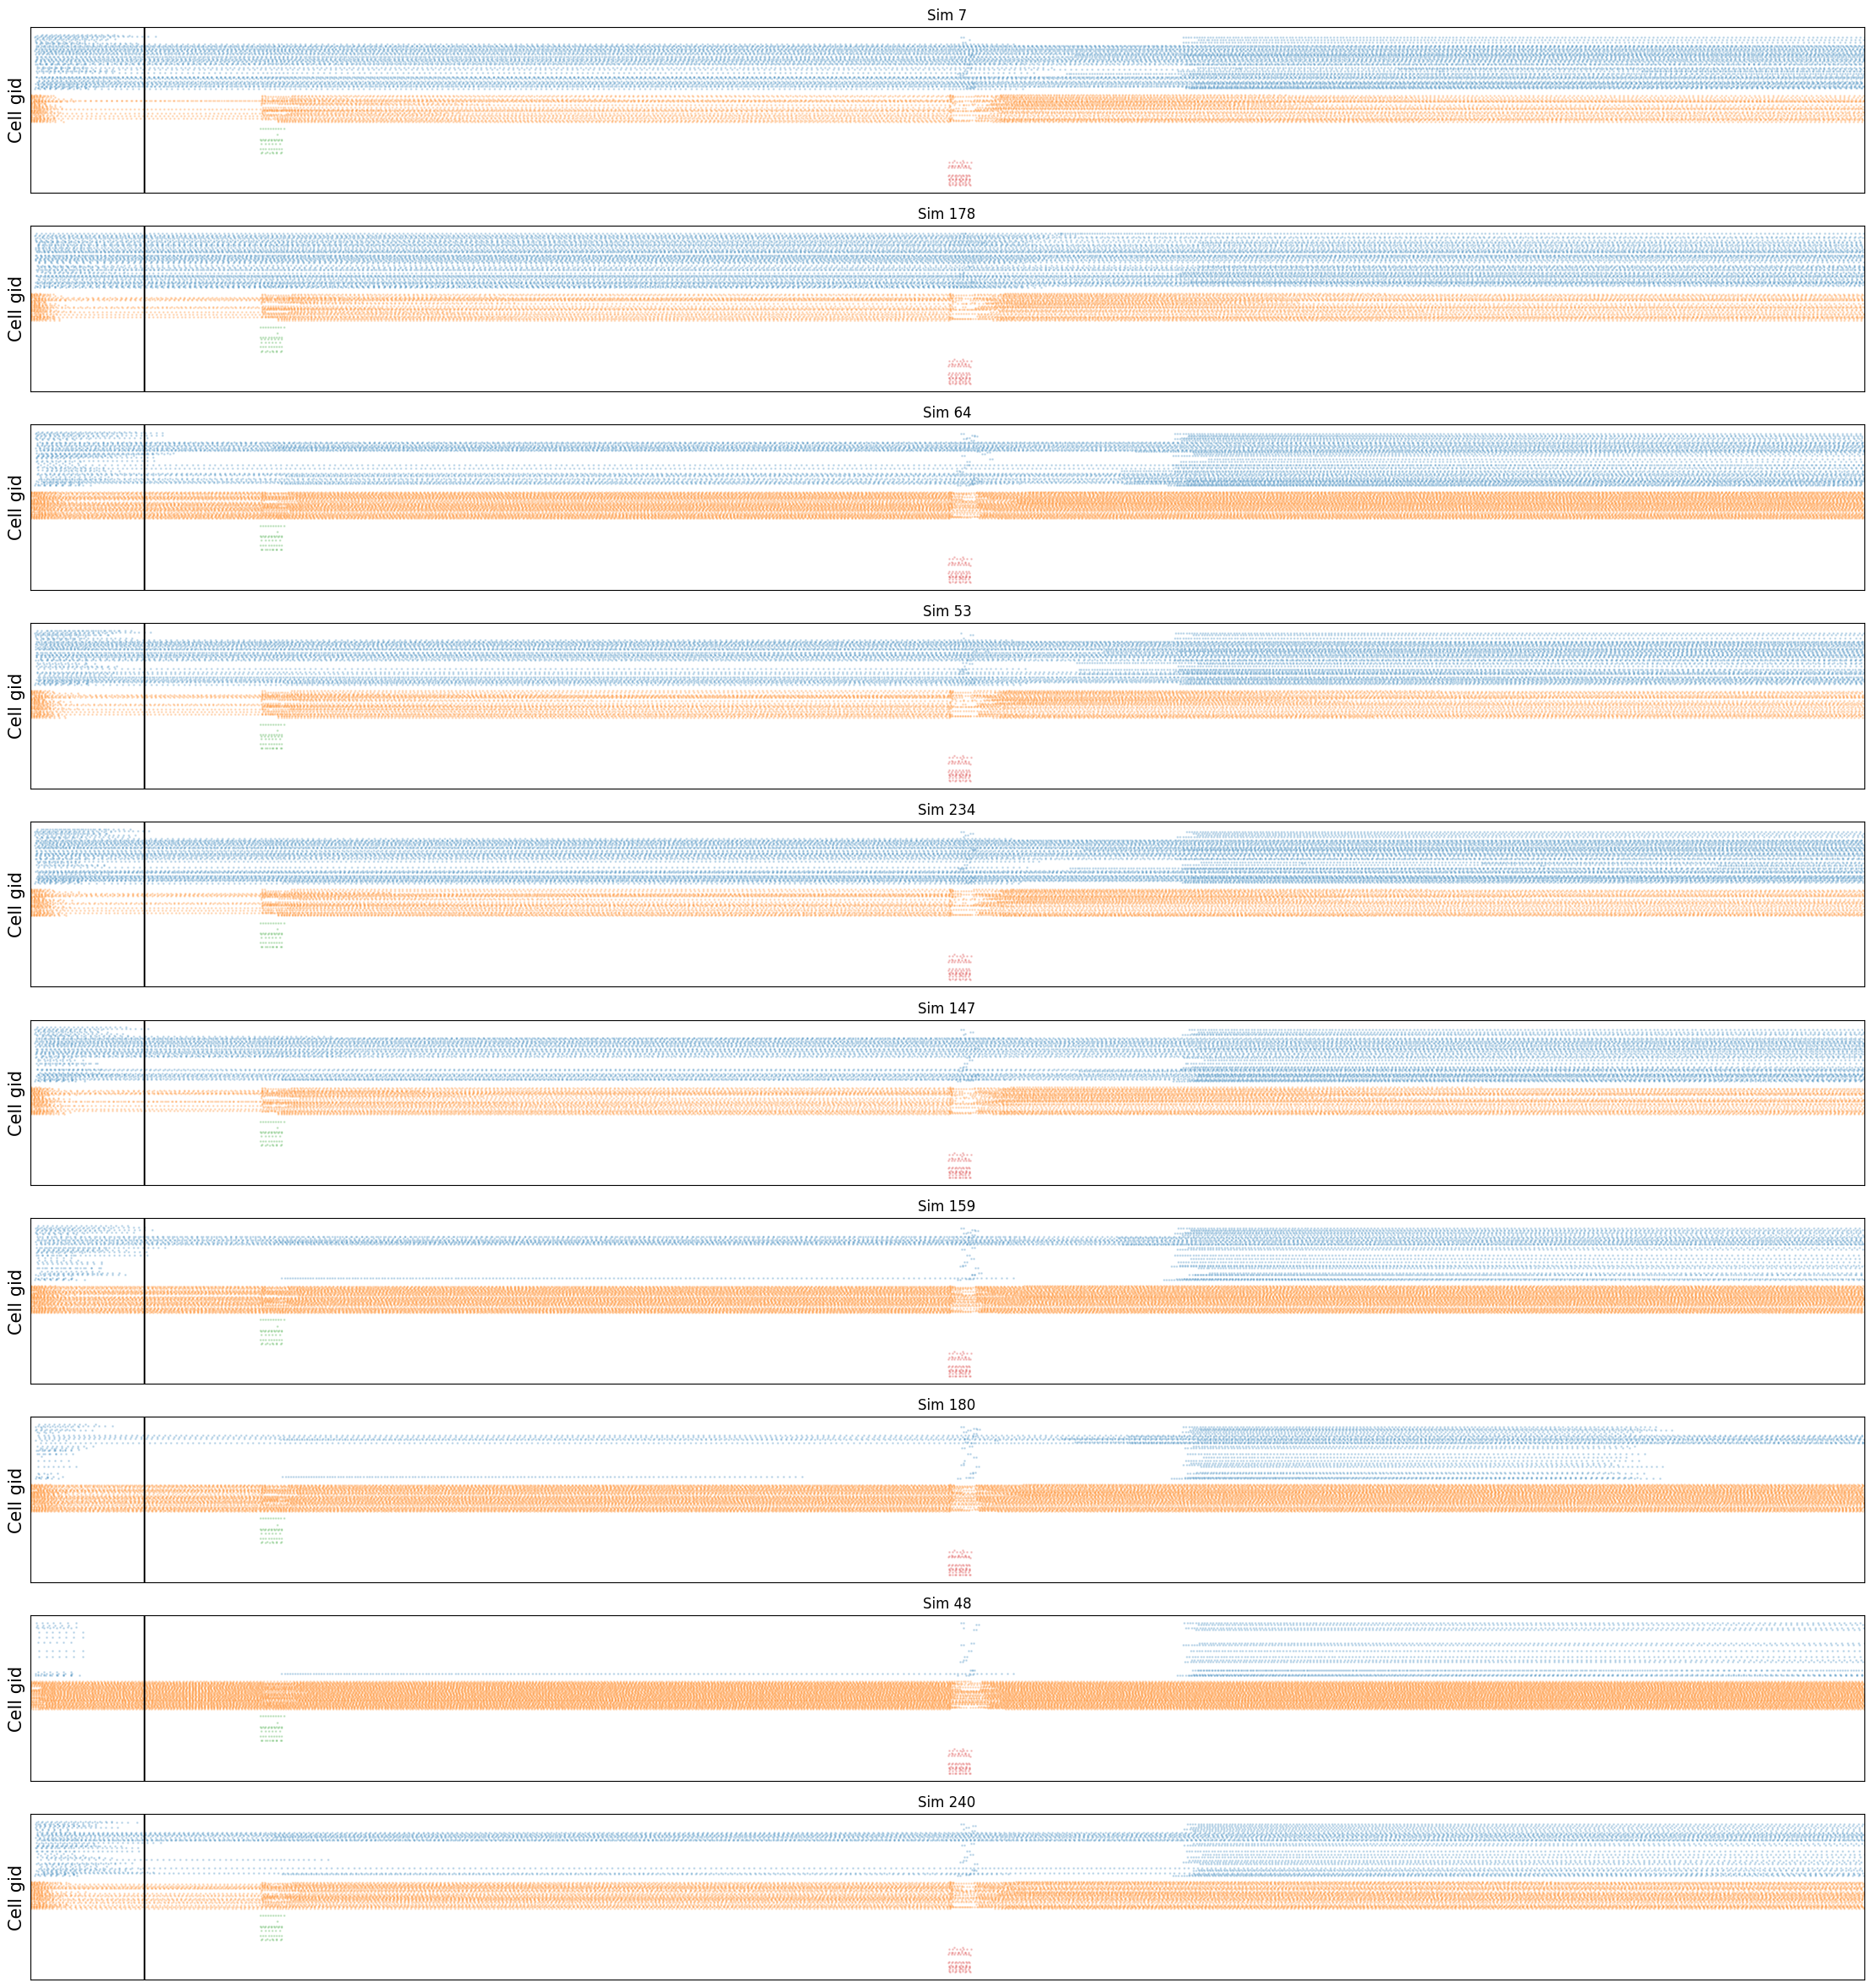

In [28]:
fontsize = 15
ticksize = 10
plt.figure(figsize=(14*2,30))
threshold = 0.0
plot_start_idx = 0

# for plot_idx, sim_idx in enumerate(range(plot_start_idx,plot_start_idx+10)):
# for plot_idx, sim_idx in enumerate(band_power_sort[plot_start_idx:plot_start_idx+10]):
for plot_idx, sim_idx in enumerate(error_sort[plot_start_idx:plot_start_idx+10]):
    plt.subplot(10, 1, plot_idx+1)
    s = x_out[sim_idx * 8 + 0, :, :]
    above_threshold = s > threshold
    spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

    for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
        if name not in ['output', 'E_rate', 'I_rate']:
            mask = np.isin(spike_gids, cell_range)
            plt.scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.2)
    # plt.legend(fontsize=fontsize)
    plt.ylabel('Cell gid', fontsize=fontsize)
    plt.xticks([])
    plt.yticks([])
    plt.xlim(0, time_vec[-1])
    plt.title(f'Sim {sim_idx}')
    plt.axvline(500 * dt, color='k')


In [29]:
prior_dict = get_prior_dict()
key_order = ["IE_gaba_gS", "II_gaba_gS", "EI_ampa_gS", "EE_ampa_gS",
                "IE_gaba_pconn", "II_gaba_pconn", "EI_ampa_pconn", "EE_ampa_pconn",
                "E_Km_gKm", "E_CaL_gCaL", "E_CaT_gCaT", "I_Km_gKm", "I_CaL_gCaL", "I_CaT_gCaT"]

# params is a list of single element dicitonaries, this is to just find the index
# key_mapping = {list(param_dict.keys())[0]: idx for idx, param_dict in enumerate(params)}
theta_dict = {param_name: prior_dict[param_name]['rescale_function'](
    theta[22, param_idx], prior_dict[param_name]['bounds']) for 
    param_idx, param_name in enumerate(key_order)}

theta_dict

{'IE_gaba_gS': 9.552242855197458e-09,
 'II_gaba_gS': 6.961082145582031e-05,
 'EI_ampa_gS': 8.550339352913116e-06,
 'EE_ampa_gS': 0.0007772919515157635,
 'IE_gaba_pconn': 0.26447390913963315,
 'II_gaba_pconn': 0.22132011651992797,
 'EI_ampa_pconn': 0.26357306241989137,
 'EE_ampa_pconn': 0.18795467019081116,
 'E_Km_gKm': 1.5328519283728717e-07,
 'E_CaL_gCaL': 1.6975960184549798e-08,
 'E_CaT_gCaT': 5.629389261689836e-05,
 'I_Km_gKm': 5.7029142289522333e-05,
 'I_CaL_gCaL': 1.2463285771443473e-08,
 'I_CaT_gCaT': 6.72417370682042e-06}

In [30]:
# df = pd.DataFrame(theta)
# sns.pairplot(df)

In [33]:
sim_idx = error_sort[0]

x_train_list = list()
for cond_idx in range(num_cond):
    x_train_list.append(output_array[sim_idx * num_cond + cond_idx, gid_ranges['E_rate'], :])
x_train = np.concatenate(x_train_list, axis=1).T

# model = LinearRegression()
model = Ridge(alpha=2.0)
y_pred = model.fit(x_train[burn_in:, :], targets[burn_in:, :]).predict(x_train[burn_in:, :])
error = np.mean(np.square(targets[burn_in:, :] - y_pred))
W_out = model.coef_
b_out = model.intercept_
print(error)

0.1579633042319106


Text(0.5, 0, 'Time (ms)')

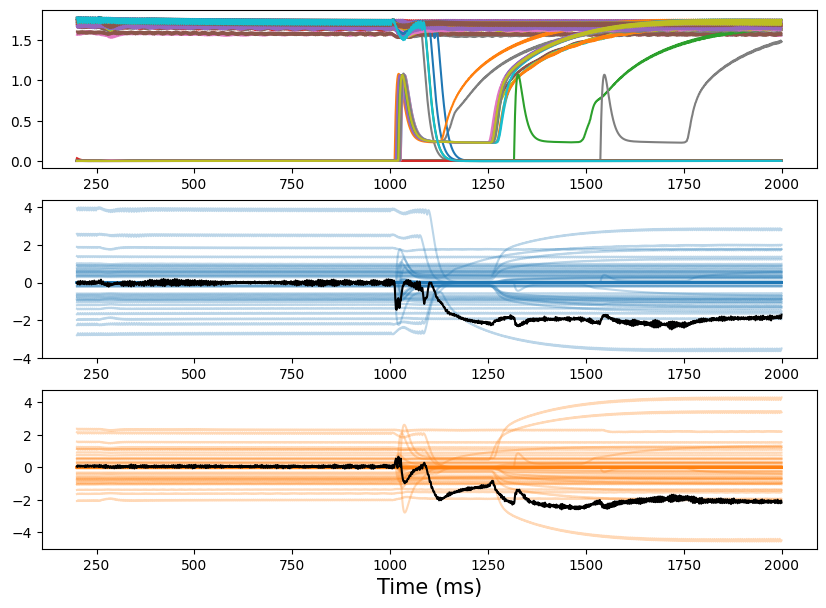

In [34]:
cond_idx = 0
output = jnp.matmul(W_out, x_out[sim_idx*8 + cond_idx, list(gid_ranges['E_rate']), :]).squeeze() + b_out.reshape(-1,1)

plt.figure(figsize=(10,7))
plt.subplot(3,1,1)
_ = plt.plot(time_vec[burn_in:], x_out[sim_idx*8 + cond_idx, list(gid_ranges['E_rate']), burn_in:-1].T)
plt.subplot(3,1,2)
_ = plt.plot(time_vec[burn_in:], x_out[sim_idx*8 + cond_idx, list(gid_ranges['E_rate']), burn_in:-1].T * W_out[0,:], color='C0', alpha=0.3)
plt.plot(time_vec[burn_in:], output[0,burn_in:-1], color='k')
plt.subplot(3,1,3)
_ = plt.plot(time_vec[burn_in:], x_out[sim_idx*8 + cond_idx, list(gid_ranges['E_rate']), burn_in:-1].T * W_out[1,:], color='C1', alpha=0.3)
plt.plot(time_vec[burn_in:], output[1,burn_in:-1], color='k')

plt.xlabel('Time (ms)', fontsize=15)


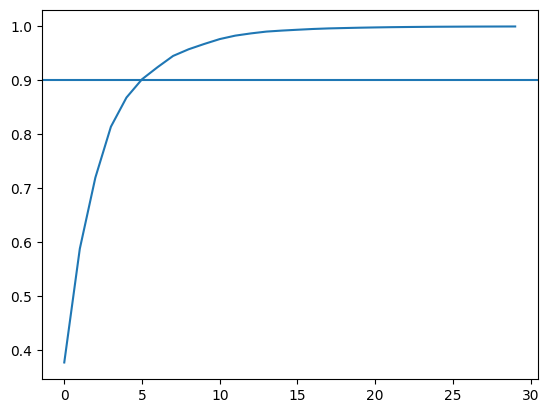

In [35]:
pca = PCA(n_components=30)
pca_states = pca.fit(x_train)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.9)

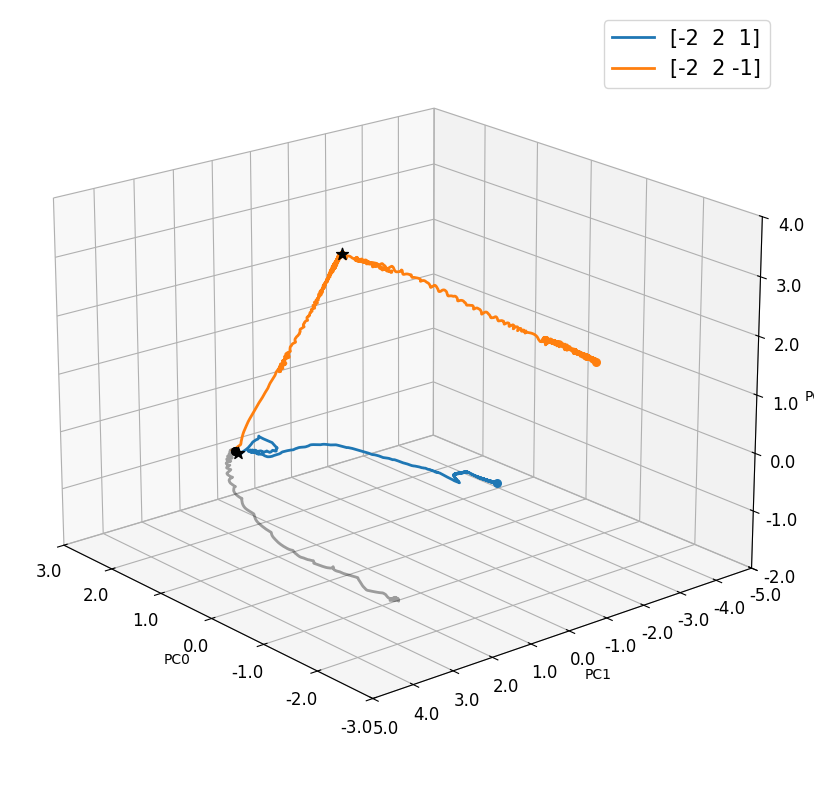

In [36]:
%matplotlib inline
dim1, dim2, dim3 = 0,1,2

start_idx = 2000 // downsample_factor
stop_idx = 80_000 // downsample_factor

context_idx = 10_000 // downsample_factor
cue_idx = 40_000 // downsample_factor

ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')
for plot_idx, idx in enumerate([2,6]):
# for plot_idx, idx in enumerate([2,3,6,7]):
# for plot_idx, idx in enumerate([0,4,1,5]):
    res_pca = pca.transform(x_train_list[idx].T)
    ax.plot(res_pca[start_idx:context_idx,dim1], res_pca[start_idx:context_idx,dim2], res_pca[start_idx:context_idx,dim3],linewidth=2, color='k' , alpha=0.2)
    ax.plot(res_pca[context_idx:stop_idx,dim1], res_pca[context_idx:stop_idx,dim2], res_pca[context_idx:stop_idx,dim3],linewidth=2, color=f'C{plot_idx}' , alpha=1, label=str(input_list[idx]))
    ax.scatter(res_pca[context_idx,dim1], res_pca[context_idx,dim2], res_pca[context_idx,dim3], color='k', s=30)
    ax.scatter(res_pca[cue_idx,dim1], res_pca[cue_idx,dim2], res_pca[cue_idx,dim3], color='k', marker='*', s=80)
    ax.scatter(res_pca[stop_idx,dim1], res_pca[stop_idx,dim2], res_pca[stop_idx,dim3], color=f'C{plot_idx}', s=30)
    # ax.scatter(res_pca[-1,dim1], res_pca[-1,dim2], res_pca[-1:,dim3], color='k', s=100, marker='*')
 
    plt.legend(fontsize=15)
ax.view_init(elev=20., azim=140, roll=0)
ax.set_xticks(ticks=ax.get_xticks(), labels=ax.get_xticks(), fontsize=12)
ax.set_yticks(ticks=ax.get_yticks(), labels=ax.get_yticks(), fontsize=12)
ax.set_zticks(ticks=ax.get_zticks(), labels=ax.get_zticks(), fontsize=12)
ax.set_xlabel(f'PC{dim1}')
ax.set_ylabel(f'PC{dim2}')
ax.set_zlabel(f'PC{dim3}')


xlim, ylim, zlim = ax.get_xlim(), ax.get_ylim(), ax.get_zlim()

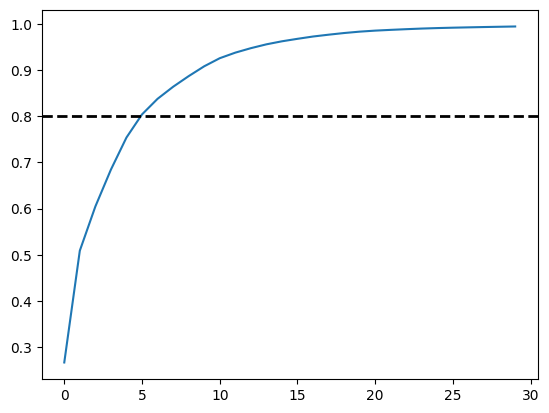

In [22]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.8, color='k', linewidth=2, linestyle='--')